# How does life expectancy correlate with a country's GDP?

We will explore 6 countries (Chile, Mexico, the USA, China, Germany, and Zimbabwe) and their populations' life expectancy, as well as their country's GDP.

1. We will explore the comparison between the countries' GDP.
2. We will explore how life expectancy has changed over the years that are provided in the data.
3. We will explore if there is a correlation between GDP and life expectancy.
4. We will explore the life expectancy in each nation compared to others.

All of this will be displayed in graphs so we can better visualize the data.

## Data sources

GDP Source: World Bank national accounts data, and OECD National Accounts data files.
Life expectancy Data Source: World Health Organization

In [92]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

#### Firstly, we will explore our data

In [8]:
df = pd.read_csv('all_data.csv')
df.head()

,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


In [9]:
df.shape

(96, 4)

We can see that our data consists of 4 columns and 96 rows. The first column shows countries, the second shows the years that we will explore, the third shows life expectancy at birth in years for each year, and the fourth shows the country's GDP in trillions of dollars.

In [16]:
print(df.Country.unique())

<StringArray>
['Chile', 'China', 'Germany', 'Mexico', 'United States of America',
 'Zimbabwe']
Length: 6, dtype: str


In [12]:
print(df.Year.unique())

[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015]


We can see that in our data, the countries we will be exploring are Chile, China, Germany, Mexico, the United States of America, and Zimbabwe. The years from which we will gather our data span from 2000 to 2015.

In [24]:
df = df.rename(columns={'Life expectancy at birth (years)': 'LEAB_years'})

In [25]:
print(df.head())

  Country  Year  LEAB_years           GDP
0   Chile  2000        77.3  7.786093e+10
1   Chile  2001        77.3  7.097992e+10
2   Chile  2002        77.8  6.973681e+10
3   Chile  2003        77.9  7.564346e+10
4   Chile  2004        78.0  9.921039e+10


For easier coding, so we don't have to write "Life expectancy at birth (years)", we shortened it to LEAB_years. 

### Plotting graphs to show us answers regarding GDP and life expectancy
Firstly, we will explore how countries' GDP has changed throughout the years. Each country is represented by its color as seen in the legend.

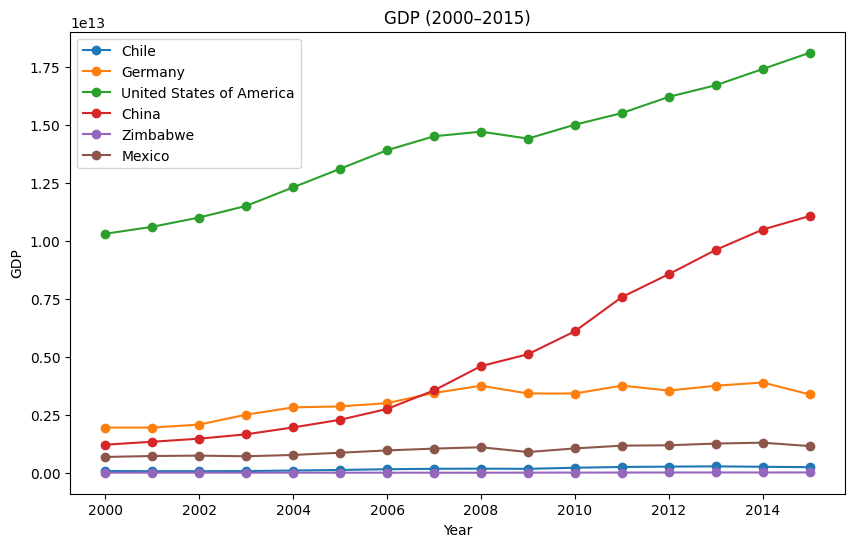

<Figure size 640x480 with 0 Axes>

In [105]:
countries = ['Chile', 'Germany', 'United States of America', 'China', 'Zimbabwe', 'Mexico']
df_selected = df[df['Country'].isin(countries)]
plt.figure(figsize=(10, 6))
for country in countries:
    country_df = df_selected[df_selected['Country'] == country]
    country_df = country_df.sort_values('Year')
    plt.plot(country_df['Year'], country_df['GDP'], marker='o', label=country)

plt.xlabel('Year')
plt.ylabel('GDP')
plt.title('GDP (2000–2015)')
plt.legend()
plt.show()
plt.clf()

The next step is to see how average life expectancy has changed throughout the years for all countries together.

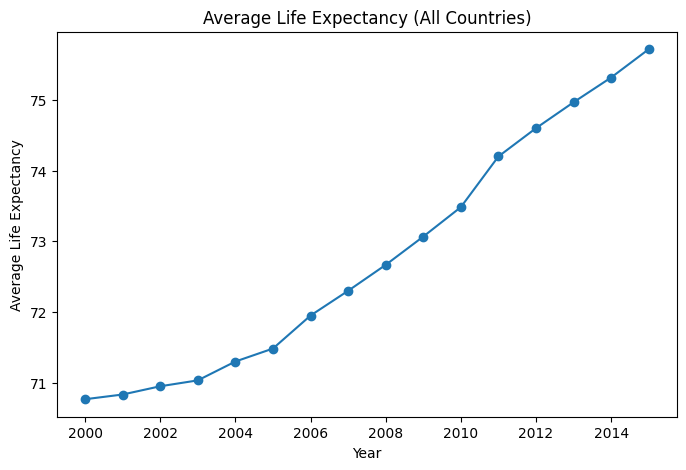

<Figure size 640x480 with 0 Axes>

In [63]:
avg_le_by_year = df.groupby('Year')['LEAB_years'].mean()
plt.figure(figsize=(8, 5))
plt.plot(avg_le_by_year.index, avg_le_by_year.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Average Life Expectancy')
plt.title('Average Life Expectancy (All Countries)')
plt.show()
plt.clf()

While the previous graph has shown that life expectancy has continuously grown during the years, if we inspect it for each country individually, we get more nuanced results. 

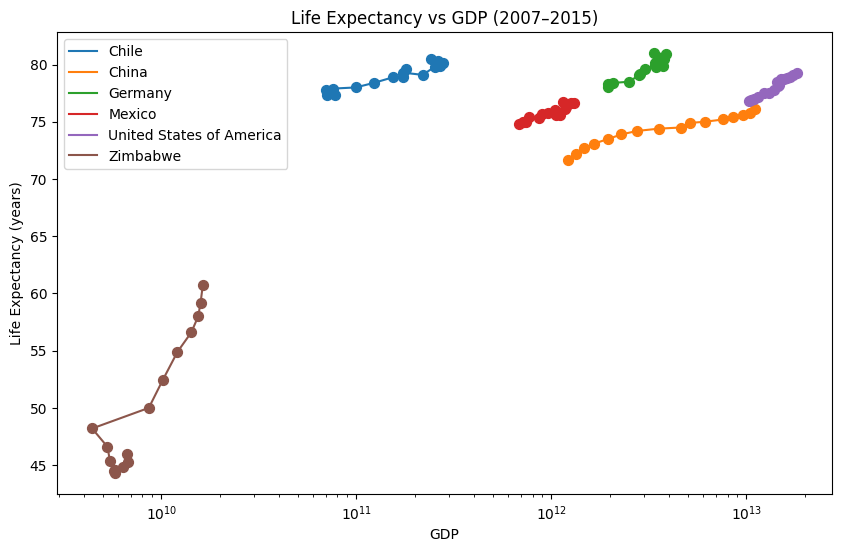

<Figure size 640x480 with 0 Axes>

In [104]:
plt.figure(figsize=(10, 6))
for country in df['Country'].unique():
    country_df = df[df['Country'] == country].sort_values('Year')
    plt.scatter(country_df['GDP'], country_df['LEAB_years'], s=50)
    plt.plot(country_df['GDP'], country_df['LEAB_years'], label=country)
plt.xscale('log')  
plt.xlabel('GDP')
plt.ylabel('Life Expectancy (years)')
plt.title('Life Expectancy vs GDP (2007–2015)')
plt.legend()
plt.show()
plt.clf()

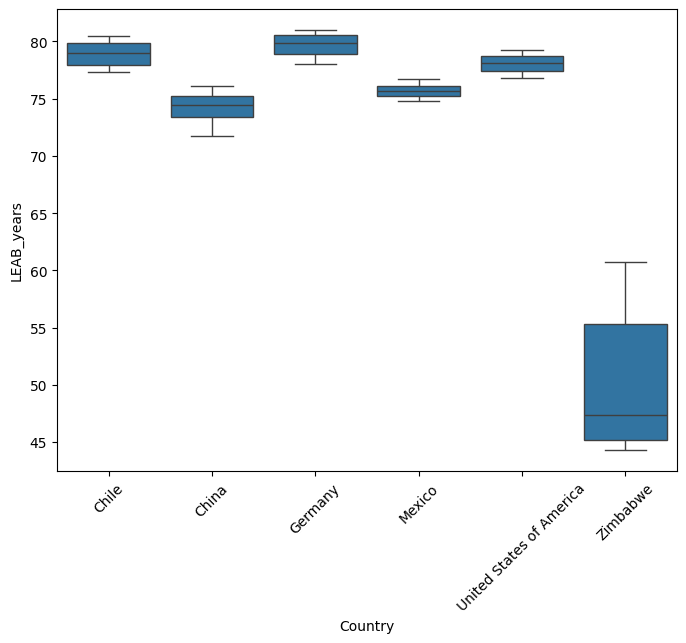

<Figure size 640x480 with 0 Axes>

In [103]:
plt.figure(figsize = (8, 6))
sns.boxplot(data = df, x = 'Country', y = 'LEAB_years')
plt.xticks(rotation = 45)
plt.show()
plt.clf()

In our last graph, we can see clearly how the life expectancy of one country measures against that of the others. The blue squares represent the majority, while the vertical lines represent the error margin. We can see that there are the most outliers in Zimbabwe, which makes our error margin lines higher and lower.

## Conclusion
In the end, we got our information about GDP and life expectancy at birth. We have learned that GDP is steadily growing in all countries, and that the same goes for life expectancy. This shows us that GDP and life expectancy are correlated. 